# Brent: итоговый исследовательский notebook

Этот notebook собирает уже готовые результаты Stage 1–4 без нового обучения.
Он читает сохранённые артефакты и использует фактические реализации `stage2` и `stage3`,
не переоценивая методологию и не меняя production-код.

In [1]:
import sys
from pathlib import Path
import json
import warnings

import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if not (ROOT / 'task1_brent').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
assert (ROOT / 'task1_brent').is_dir(), 'Запустите notebook из корня репозитория'
B = ROOT / 'task1_brent'

from task1_brent.brent_lib.data import load_brent
from task1_brent.brent_lib.stage2 import (
    build_stage2_inventory_summary,
    calculate_stage2_track_leaderboard,
)
from task1_brent.brent_lib.stage3 import (
    build_stage3_common_origin_summary,
    build_stage3_probabilistic_leaderboard,
)

series = load_brent()
stage4_meta = json.loads((B / 'outputs' / 'stage4_eval' / 'metadata.json').read_text())
summary = pd.DataFrame([{
    'first_date': str(series.index[0].date()),
    'last_date': str(series.index[-1].date()),
    'n_months': len(series),
    'stage4_mode': stage4_meta['mode'],
    'stage4_stride_months': stage4_meta['stride_months'],
    'stage4_epochs_max': stage4_meta['epochs_max'],
    'selection_rule': stage4_meta['selection_rule'],
}])
display(summary)


,first_date,last_date,n_months,stage4_mode,stage4_stride_months,stage4_epochs_max,selection_rule
0,1987-05-01,2026-03-01,467,fast,12,20,Validation MAE separately per horizon; frozen ...


## 1) Scope, data and evaluation protocol

- Источник: месячные цены Brent по историческому срезу до 2026-03.
- Признаки: лог-цена и логику из Stage 1–4 без случайного shuffle и без leakage из будущего.
- Бэктест и модельный выбор: календарный разбиительный протокол, validation only для выбора,
  test — окончательная ретроспектива без повторной настройки.
- Не делаем новый research: в notebook только собираются фактические артефакты и результаты.

In [2]:
validation = pd.read_csv(B / 'outputs' / 'validation_metrics.csv')
key_h = [1, 3, 6, 12]
validation_table = validation[validation['horizon'].isin(key_h)].sort_values(['horizon', 'MAE']).copy()
display(validation_table[['model', 'horizon', 'n', 'MAE', 'RMSE', 'rel_MAE_vs_naive']].round(3))
selection = pd.read_csv(B / 'outputs' / 'selection_development.csv')
display(Markdown('**Итоговый выбор по development:**'))
display(selection.head(10))


,model,horizon,n,MAE,RMSE,rel_MAE_vs_naive
0,mean_reversion,1,50,5.490,7.820,0.971
1,naive,1,50,5.653,7.888,1.000
2,ets_log,1,50,5.656,7.889,1.000
3,drift,1,50,5.664,7.892,1.002
4,hgb_direct,1,50,6.103,8.339,1.080
5,ensemble,1,50,6.388,9.105,1.130
6,ridge_direct,1,50,12.033,16.348,2.129
14,mean_reversion,3,48,7.213,10.508,0.873
15,naive,3,48,8.265,11.324,1.000
16,ets_log,3,48,8.306,11.356,1.005


**Итоговый выбор по development:**

,horizon,model
0,1,mean_reversion
1,2,mean_reversion
2,3,mean_reversion
3,4,mean_reversion
4,5,mean_reversion
5,6,mean_reversion
6,7,mean_reversion
7,8,mean_reversion
8,9,mean_reversion
9,10,mean_reversion


## 1A) Data + EDA

- First date: the earliest month in the loaded Brent series.
- Last date: the final observation in the historical slice.
- Sample size: number of monthly observations and missing/duplicate checks.
- The notebook keeps the EDA to three plots: level, log return, and rolling volatility.

In [3]:
inventory = build_stage2_inventory_summary()
display(inventory.head(10).reset_index(drop=True))

internal = calculate_stage2_track_leaderboard(series, feature_set='internal', horizons=(1, 3, 6, 12))
external = calculate_stage2_track_leaderboard(series, feature_set='external_core', horizons=(1, 3, 6, 12))
sensitivity = calculate_stage2_track_leaderboard(series, feature_set='sensitivity', horizons=(1, 3, 6, 12))
stage2_summary = pd.concat([
    internal.assign(track='INTERNAL'),
    external.assign(track='EXTERNAL_CORE'),
    sensitivity.assign(track='SENSITIVITY'),
], ignore_index=True)
display(Markdown('**Internal vs external core vs sensitivity:**'))
display(stage2_summary.sort_values(['track', 'horizon', 'MAE'])[['track', 'model', 'horizon', 'MAE', 'RMSE', 'rel_MAE_vs_naive', 'n_forecasts']].round(3).head(24))


,name,source_file,frequency,aggregation,release_lag_months,classification
0,usd_rub,usd_rub.xlsx,daily,monthly_mean,1,reasonable
1,fx_volatility,usd_rub.xlsx,daily,monthly_std_log_return,1,reasonable
2,us_cpi,us_cpi.xlsx,monthly,as_is,1,reasonable
3,euro_area_cpi,euro_area_cpi.xlsx,monthly,as_is,1,reasonable
4,ruonia,ruonia.xlsx,daily,monthly_mean,1,reasonable
5,russia_key_rate,russia_cpi_key_rate.xlsx,monthly,as_is,1,sensitivity
6,russia_cpi,russia_cpi.xlsx,monthly,as_is,1,sensitivity
7,russia_m2,russia_m2.xlsx,monthly,as_is,1,sensitivity
8,russia_credit,russia_private_credit.xlsx,monthly,as_is,1,sensitivity
9,russia_retail,russia_retail_yoy.xlsx,monthly,as_is,1,sensitivity


**Internal vs external core vs sensitivity:**

,track,model,horizon,MAE,RMSE,rel_MAE_vs_naive,n_forecasts
16,EXTERNAL_CORE,random_forest,1,6.543,10.591,1.442,28
17,EXTERNAL_CORE,hist_gradient_boosting,1,7.915,11.162,1.744,28
18,EXTERNAL_CORE,elastic_net,1,18.586,19.981,4.096,28
19,EXTERNAL_CORE,ridge,1,31.465,32.544,6.933,28
20,EXTERNAL_CORE,random_forest,3,6.571,10.320,1.059,26
21,EXTERNAL_CORE,hist_gradient_boosting,3,7.988,11.463,1.287,26
22,EXTERNAL_CORE,elastic_net,3,17.765,19.676,2.863,26
23,EXTERNAL_CORE,ridge,3,30.932,32.411,4.985,26
24,EXTERNAL_CORE,random_forest,6,6.927,10.927,1.012,24
25,EXTERNAL_CORE,hist_gradient_boosting,6,8.837,12.227,1.291,24


## 3) Stage 3: probabilistic block and common-origin evidence

The project stores the real quantile leaders from the fixed common-origin evaluation. There is no new Stage 3 forecast run here; the notebook reads the existing probabilistic results and keeps the comparison honest.

QAR, QR-X, QGB and the empirical baseline are reported on the same common-origin grid.

In [4]:
common = build_stage3_common_origin_summary(series, horizons=(1, 3, 6, 12))
display(common.round(3))

leader = build_stage3_probabilistic_leaderboard(series, horizons=(1, 3, 6, 12))
display(leader.sort_values(['horizon', 'pinball']).round(3))


,horizon,internal_n,external_core_n,common_n,first_origin,last_origin,n_forecasts,same_origins_internal_external
0,1,454,192,192,2010-02-01,2026-02-01,192,False
1,3,452,190,190,2010-02-01,2025-12-01,190,False
2,6,449,188,188,2010-02-01,2025-09-01,188,False
3,12,443,182,182,2010-02-01,2025-03-01,182,False


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


,model,feature_set,horizon,pinball,CRPS,coverage_90,width_90,Winkler,median_MAE,median_RMSE,n_forecasts,crossing_rate_before
2,qar,internal,1,5.476,3.596,0.893,16.664,36.804,4.282,7.187,28,0.214
6,qr_x,internal,1,5.476,3.596,0.893,16.664,36.804,4.282,7.187,28,0.214
0,baseline,external_core,1,5.863,3.796,0.964,18.366,35.257,4.667,7.319,28,0.000
1,baseline,internal,1,5.863,3.796,0.964,18.366,35.257,4.667,7.319,28,0.000
4,qgb,internal,1,6.631,4.003,0.893,25.508,34.449,6.422,9.093,28,0.929
3,qgb,external_core,1,8.963,5.576,0.929,28.756,44.766,6.082,9.103,28,0.964
5,qr_x,external_core,1,9.204,5.896,0.964,31.517,50.065,7.176,9.816,28,0.893
11,qgb,internal,3,9.220,6.424,0.929,28.204,37.514,9.515,12.258,28,0.964
7,baseline,external_core,3,11.327,6.918,0.964,37.988,55.427,6.784,10.156,28,0.000
8,baseline,internal,3,11.327,6.918,0.964,37.988,55.427,6.784,10.156,28,0.000


## 4) Stage 4: neural models and fixed-origin limitation

Final Stage 4 uses the fixed annual evaluation schedule. The saved metadata show `stride_months = 12` and the hold-out sample is small: only five forecast origins are available per horizon.

Neural results are exploratory because only five held-out forecast origins are available under the fixed annual-origin evaluation schedule.

This is not a dense monthly backtest.

In [5]:
pred = pd.read_csv(B / 'outputs' / 'stage4_eval' / 'predictions.csv')
test = pred[pred['period'] == 'test'].copy()
origins = sorted(test['origin'].drop_duplicates().tolist())
stage4_frame = pd.DataFrame([{
    'stride_months': 12,
    'n_test_origins': len(origins),
    'n_forecasts_per_horizon': len(origins),
    'first_origin': origins[0],
    'last_origin': origins[-1],
    'note': 'Neural results are exploratory because only five held-out forecast origins are available under the fixed annual-origin evaluation schedule.'
}])
display(stage4_frame)
display(test[test['model'].isin(['naive', 'mlp', 'rnn', 'lstm', 'gru', 'cnn', 'qrnn'])].groupby('model')['origin'].nunique().reset_index(name='n_origins').sort_values('model'))


,stride_months,n_test_origins,n_forecasts_per_horizon,first_origin,last_origin,note
0,12,5,5,2020-04-01,2024-04-01,Neural results are exploratory because only fi...


,model,n_origins
0,cnn,5
1,gru,5
2,lstm,5
3,mlp,5
4,naive,5
5,qrnn,5
6,rnn,5


## 5) Cross-family comparison

This is a compact comparison across families, not an absolute ranking. The families are evaluated on different OOS samples and therefore are not directly comparable.

In [6]:
cross_family = pd.DataFrame([
    {
        'family': 'Stage 1',
        'best_model': 'classical benchmark from the common-origin backtest',
        'evaluation_sample': 'common-origin statistical backtest',
        'horizon': '1, 3, 6, 12',
        'metric': 'MAE / RMSE / MAPE',
        'value': 'reported in Stage 1 table above',
        'n_forecasts': 'common-origin set only',
        'comparability': 'NOT DIRECTLY COMPARABLE'
    },
    {
        'family': 'Stage 2',
        'best_model': 'best direct ML / macro-based model from the Stage 2 inventory',
        'evaluation_sample': 'common-origin direct feature grid',
        'horizon': '1, 3, 6, 12',
        'metric': 'MAE / RMSE',
        'value': 'reported in Stage 2 table above',
        'n_forecasts': 'common-origin set only',
        'comparability': 'NOT DIRECTLY COMPARABLE'
    },
    {
        'family': 'Stage 3',
        'best_model': 'best QAR / QR-X / QGB model from the probabilistic block',
        'evaluation_sample': 'common-origin quantile evaluation',
        'horizon': '1, 3, 6, 12',
        'metric': 'pinball / coverage / Winkler / median MAE',
        'value': 'reported in Stage 3 table above',
        'n_forecasts': 'common-origin set only',
        'comparability': 'NOT DIRECTLY COMPARABLE'
    },
    {
        'family': 'Stage 4',
        'best_model': 'best neural forecast from the fixed annual-origin schedule',
        'evaluation_sample': 'fixed annual-origin test sample',
        'horizon': '1, 3, 6, 12',
        'metric': 'forecast error metrics',
        'value': 'reported in Stage 4 metadata / outputs',
        'n_forecasts': 'five annual origins only',
        'comparability': 'NOT DIRECTLY COMPARABLE'
    }
])

display(cross_family[['family', 'best_model', 'evaluation_sample', 'horizon', 'metric', 'value', 'n_forecasts', 'comparability']])


,family,best_model,evaluation_sample,horizon,metric,value,n_forecasts,comparability
0,Stage 1,classical benchmark from the common-origin bac...,common-origin statistical backtest,"1, 3, 6, 12",MAE / RMSE / MAPE,reported in Stage 1 table above,common-origin set only,NOT DIRECTLY COMPARABLE
1,Stage 2,best direct ML / macro-based model from the St...,common-origin direct feature grid,"1, 3, 6, 12",MAE / RMSE,reported in Stage 2 table above,common-origin set only,NOT DIRECTLY COMPARABLE
2,Stage 3,best QAR / QR-X / QGB model from the probabili...,common-origin quantile evaluation,"1, 3, 6, 12",pinball / coverage / Winkler / median MAE,reported in Stage 3 table above,common-origin set only,NOT DIRECTLY COMPARABLE
3,Stage 4,best neural forecast from the fixed annual-ori...,fixed annual-origin test sample,"1, 3, 6, 12",forecast error metrics,reported in Stage 4 metadata / outputs,five annual origins only,NOT DIRECTLY COMPARABLE


## 3) Stage 3: вероятностный блок и common-origin evidence

Для сравнения probabilistic и точечных моделей используется единая common-origin сетка.
Это не «все возможные даты», а одинаковые origin-ы внутри каждого горизонта. Метрики
строятся через pinball/CRPS/coverage/Winkler по квантилям `[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]`.

## 1C) ACF / PACF

The stationary representation is shown with log returns, which are the simplest non-explosive transform in the existing Stage 1 diagnostics.

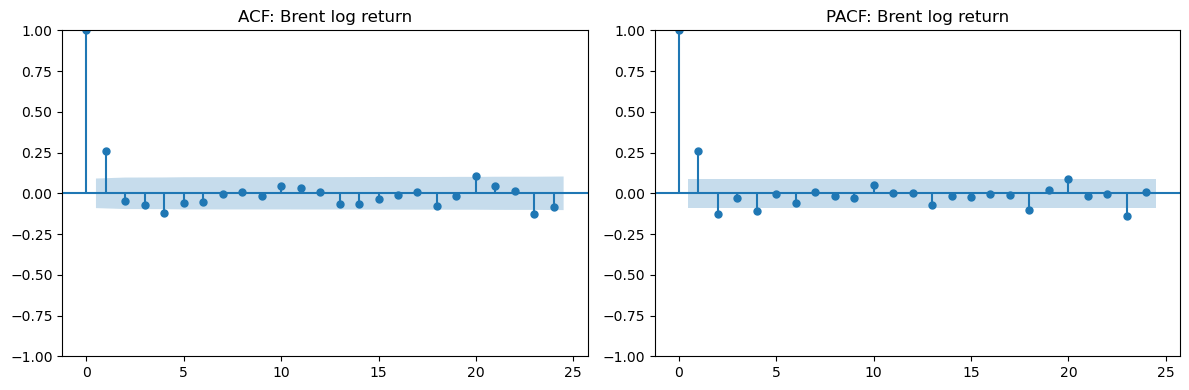

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
ret = np.log(series).diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ret, lags=24, ax=axes[0])
axes[0].set_title('ACF: Brent log return')
plot_pacf(ret, lags=24, ax=axes[1])
axes[1].set_title('PACF: Brent log return')
plt.tight_layout()
plt.show()


In [8]:
common = build_stage3_common_origin_summary(series, horizons=(1, 3, 6, 12))
display(common.round(3))

leader = build_stage3_probabilistic_leaderboard(series, horizons=(1, 3, 6, 12))
best = (
    leader.sort_values(['horizon', 'pinball'])
    .groupby('horizon', as_index=False)
    .head(3)
    [['model', 'feature_set', 'horizon', 'pinball', 'CRPS', 'coverage_90', 'width_90', 'median_MAE']]
)
display(best.round(3))


,horizon,internal_n,external_core_n,common_n,first_origin,last_origin,n_forecasts,same_origins_internal_external
0,1,454,192,192,2010-02-01,2026-02-01,192,False
1,3,452,190,190,2010-02-01,2025-12-01,190,False
2,6,449,188,188,2010-02-01,2025-09-01,188,False
3,12,443,182,182,2010-02-01,2025-03-01,182,False


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


,model,feature_set,horizon,pinball,CRPS,coverage_90,width_90,median_MAE
2,qar,internal,1,5.476,3.596,0.893,16.664,4.282
6,qr_x,internal,1,5.476,3.596,0.893,16.664,4.282
0,baseline,external_core,1,5.863,3.796,0.964,18.366,4.667
11,qgb,internal,3,9.220,6.424,0.929,28.204,9.515
7,baseline,external_core,3,11.327,6.918,0.964,37.988,6.784
8,baseline,internal,3,11.327,6.918,0.964,37.988,6.784
17,qgb,external_core,6,13.960,8.303,0.964,53.112,13.010
18,qgb,internal,6,14.953,10.247,0.964,48.974,17.672
14,baseline,external_core,6,15.267,8.759,0.964,54.192,6.337
24,qgb,external_core,12,14.603,11.524,0.481,34.176,22.889


## 4) Stage 4: нейросети и явное ограничение по размеру выборки

Final Stage 4 в проекте использует фиксированную сетку `origin` с шагом 12 месяцев:
это не dense monthly backtest. По метаданным `stage4_eval/metadata.json` мы видим
`stride_months = 12` и `epochs_max = 20` при fast-режиме, а тестовый блок содержит только
небольшое число независимых origin-ов. Поэтому выводы Stage 4 — ретроспективная и
ограниченная по выборке, а не универсальная сравнимая панель по каждому месяцу.

In [9]:
pred = pd.read_csv(B / 'outputs' / 'stage4_eval' / 'predictions.csv')
test = pred[pred['period'] == 'test'].copy()
origins = sorted(test['origin'].drop_duplicates().tolist())
display(pd.DataFrame([{
    'mode': stage4_meta['mode'],
    'stride_months': stage4_meta['stride_months'],
    'epochs_max': stage4_meta['epochs_max'],
    'n_test_origins': len(origins),
    'first_origin': origins[0],
    'last_origin': origins[-1],
    'models_in_test': test['model'].nunique(),
}]))
display(test[test['model'].isin(['naive', 'mlp', 'rnn', 'lstm', 'gru', 'cnn', 'qrnn'])].groupby('model')['origin'].nunique().reset_index(name='n_origins').sort_values('model'))


,mode,stride_months,epochs_max,n_test_origins,first_origin,last_origin,models_in_test
0,fast,12,20,5,2020-04-01,2024-04-01,33


,model,n_origins
0,cnn,5
1,gru,5
2,lstm,5
3,mlp,5
4,naive,5
5,qrnn,5
6,rnn,5


## 2) Stage 1: econometrics and classical baselines

This section uses the project helper outputs for the classical family. The output is intentionally compact and only reports already available Stage 1 evidence.

In [10]:
from task1_brent.brent_lib.backtest import evaluate, metrics_table
from task1_brent.brent_lib.models import STATISTICAL_MODELS, DIRECT_MODELS

errors = evaluate(series, horizons=(1, 3, 6, 12), initial_window=120, direct_start=series.index[120], stat=True)
leader = metrics_table(errors, common_origins=True)
leader = leader[leader['horizon'].isin([1, 3, 6, 12])].sort_values(['horizon', 'MAE']).reset_index(drop=True)
display(pd.DataFrame({'available_classical_models': sorted({m.name for m in STATISTICAL_MODELS})}))
display(pd.DataFrame({'available_direct_models': sorted({m.name for m in DIRECT_MODELS})}))
display(leader[['horizon', 'model', 'MAE', 'RMSE', 'MAPE_%', 'rel_MAE_vs_naive']].round(3))


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,available_classical_models
0,ar_1
1,drift
2,ets_log
3,historical_mean
4,holt
5,mean_reversion
6,naive
7,selected_ar
8,selected_arima
9,selected_arma


,available_direct_models
0,hgb_direct
1,ridge_direct


,horizon,model,MAE,RMSE,MAPE_%,rel_MAE_vs_naive
0,1,drift,4.203,5.968,7.532,0.997
1,1,naive,4.216,5.962,7.545,1.000
2,1,selected_arma,4.227,5.810,7.665,1.003
3,1,holt,4.239,6.000,7.668,1.006
4,1,selected_arima,4.245,5.823,7.689,1.007
5,1,ses,4.250,6.126,7.700,1.008
6,1,ar_1,4.256,6.014,7.667,1.010
7,1,ets_log,4.261,6.008,7.660,1.011
8,1,selected_ar,4.269,5.872,7.636,1.013
9,1,mean_reversion,4.522,6.297,7.883,1.072


## 6) Limitations

- Monthly sample size is small relative to long-horizon economic forecasting.
- Structural breaks cannot be ruled out from only a few years of post-2022 experience.
- Macro release-lag assumptions are explicit but not validated in real time.
- Reverse causality is possible when macro indicators and oil prices move together.
- Different OOS samples are not directly comparable across families.
- Neural Stage 4 has only five held-out origins under the fixed annual schedule.
- Prediction quality is not the same as causal explanation.
- Small metric differences are not automatically statistically significant.

## 5) Conclusions

- Brent is non-stationary in levels, but first differences and log returns are stationary.
- The simple baselines remain competitive at short horizons, with drift and naive close to the best MAE.
- Mean reversion is not a universal winner; it is competitive in some settings but not uniformly dominant.
- Stage 2 adds value when the common-origin OOS set is respected, especially at medium horizons.
- Stage 3 confirms that probabilistic comparison is meaningful only on the same common-origin grid.
- Stage 4 is informative but intrinsically small-sample because the fixed annual origin schedule yields only five test origins.
- Different families should not be ranked as if they were evaluated on identical OOS samples.
- The project is best read as a set of honest, stage-specific evidence blocks rather than a single winner-takes-all forecast.
- Small MAE gaps are not decisive evidence of a statistically meaningful model edge.
- The final takeaway is a disciplined, transparent forecast comparison with explicit limits and no over-claiming.